# Phase 2: Building the Recommendation Graph

In this phase, we move from **tabular data** (rows and columns) to a **graph structure**. This is a fundamental shift in how we think about recommendations.

## What is a Bipartite Graph?
A bipartite graph is a special type of network where nodes are divided into two disjoint sets, $U$ (Users) and $V$ (Movies). Edges only exist between a user and a movie; there are no edges between two users or two movies.

### Why do we need this for Link Prediction?
Standard recommendation algorithms like Matrix Factorization see a grid of numbers. Graph-based algorithms see a **neighborhood**. By building a graph, we can use network science metrics (like *Common Neighbors*) to predict where new links will form.

## Step 1: Defining the 'Ground Truth' Edges

In the MovieLens dataset, we have ratings from 1 to 5. However, Link Prediction usually works on a binary state: **Does a link exist?**

To make our recommender useful, we only want to predict links that represent **affinity** (a user liking a movie). Therefore, we filter the dataset to keep only ratings of 4 or 5. These are our 'Positive Interactions'.

By discarding ratings 1-3, we ensure the graph only contains links we actually want to 'copy' when making recommendations.

In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from networkx.algorithms import bipartite

# 1. Load the ratings data
ratings_cols = ['user_id', 'movie_id', 'rating', 'timestamp']
df = pd.read_csv('data/u.data', sep='\t', names=ratings_cols)

# 2. Filter for positive interactions (Rating >= 4)
positive_df = df[df['rating'] >= 4].copy()

print(f"Total Interactions in Dataset: {len(df)}")
print(f"Positive Edges to be Added: {len(positive_df)}")
positive_df.head()

Total Interactions in Dataset: 100000
Positive Edges to be Added: 55375


,user_id,movie_id,rating,timestamp
5,298,474,4,884182806
7,253,465,5,891628467
11,286,1014,5,879781125
12,200,222,5,876042340
16,122,387,5,879270459


## Step 2: Avoiding Node ID Collision

Most graph libraries (including NetworkX) identify nodes by their unique ID. In our dataset, we have User ID 1 and Movie ID 1.

If we simply add '1' as a node, the graph won't know if it's a person or a film. To solve this, we create **typed identifiers**:
- **u_1**: Indicates User 1
- **m_1**: Indicates Movie 1

This simple prefix ensures that our User Set and Movie Set remain disjoint, which is the definition of a bipartite graph.

In [2]:
# Create unique node names
positive_df['user_node'] = 'u_' + positive_df['user_id'].astype(str)
positive_df['movie_node'] = 'm_' + positive_df['movie_id'].astype(str)

user_nodes = positive_df['user_node'].unique().tolist()
movie_nodes = positive_df['movie_node'].unique().tolist()

print(f"Unique User Nodes: {len(user_nodes)}")
print(f"Unique Movie Nodes: {len(movie_nodes)}")

Unique User Nodes: 942
Unique Movie Nodes: 1447


## Step 3: Initializing the Graph

Now we use `networkx` to create the object. We perform three key actions here:
1. **Initialize `nx.Graph()`**: This creates an undirected graph.
2. **Add Nodes with Attributes**: We assign `bipartite=0` to users and `bipartite=1` to movies. Many algorithms in NetworkX use this attribute to distinguish between the two sets.
3. **Add Edges**: We connect the nodes based on our filtered 'positive' ratings.

In [5]:
G = nx.Graph()

# 1. Add User Nodes
G.add_nodes_from(user_nodes, bipartite=0)

# 2. Add Movie Nodes
G.add_nodes_from(movie_nodes, bipartite=1)

# 3. Add Edges between them
edges = list(zip(positive_df['user_node'], positive_df['movie_node']))
G.add_edges_from(edges)

print(f"Graph Summary: {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")
print(f"Is the graph bipartite? {bipartite.is_bipartite(G)}")

Graph Summary: 2389 nodes and 55375 edges.
Is the graph bipartite? True


## Step 4: Enhancing Nodes with Metadata

A graph of 'm_1' and 'u_1' is hard for humans to understand. To make our future recommendations 'explainable', we load the movie titles from `u.item` and attach them to our movie nodes.

This allows us to ask the graph: *"What is the name of movie node m_50?"* instead of just seeing an ID.

In [6]:
# Load movie data for titles
items_cols = ['movie_id', 'title', 'release_date', 'video_release_date', 'imdb_url'] + [f'genre_{i}' for i in range(19)]
items = pd.read_csv('data/u.item', sep='|', names=items_cols, encoding='latin-1')

# Create a mapping dictionary
titles_dict = { f"m_{row['movie_id']}": row['title'] for _, row in items.iterrows() }

# Inject title attribute into the graph nodes
nx.set_node_attributes(G, titles_dict, 'title')

print("Metadata added. Example node lookup:")
print(f"Data for 'm_1': {G.nodes['m_1']}")

Metadata added. Example node lookup:
Data for 'm_1': {'bipartite': 1, 'title': 'Toy Story (1995)'}


## Step 5: Visualizing a User's 'Ego Network'

Because the graph has ~2,500 nodes, drawing the whole thing would look like a giant hairball. Instead, we visualize a **Subgraph**.

We will pick **User 1 (u_1)** and visualize every movie they have 'liked' (linked to). This type of visualization helps us verify that our graph construction is correct.

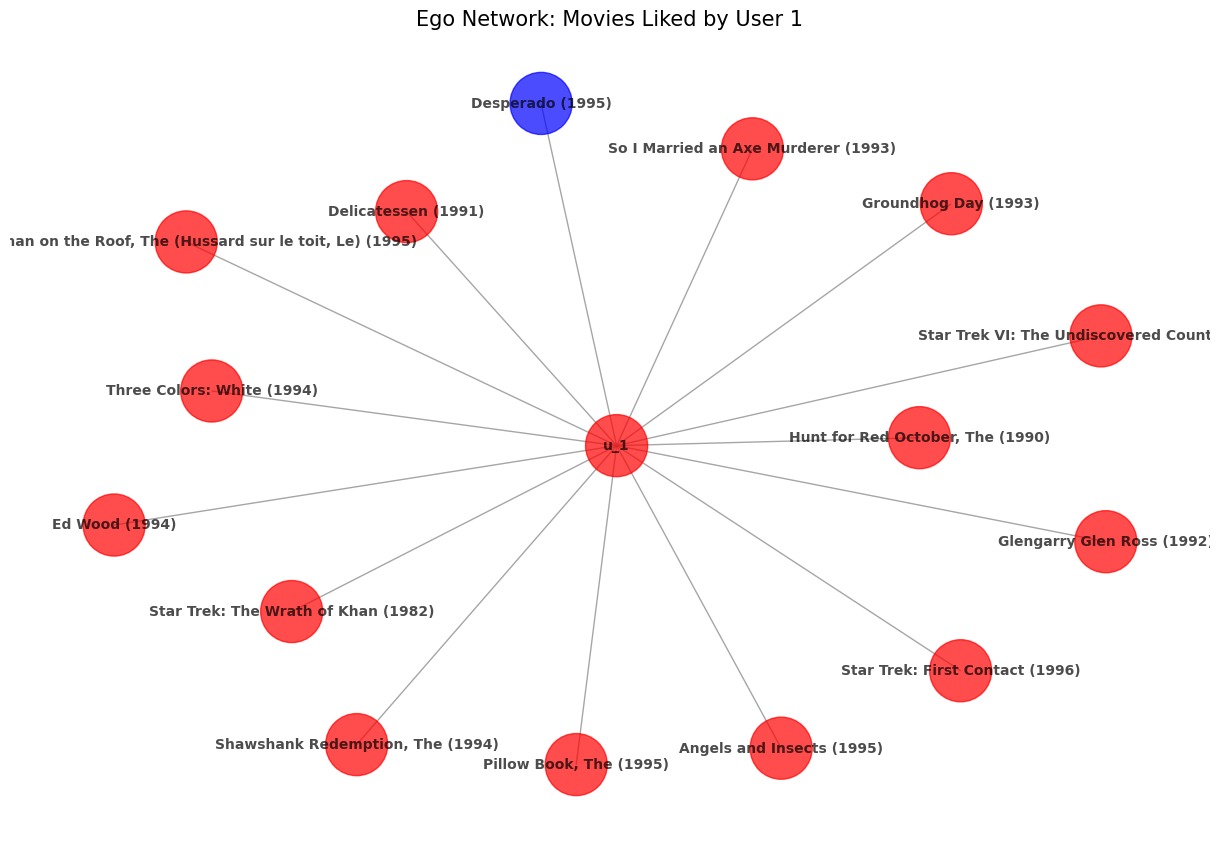

In [10]:
# 1. Select User 1
target_user = 'u_1'
neighbors = list(G.neighbors(target_user))

# 2. Create a subgraph containing only the user and their first 10 likes for clarity
sub_nodes = [target_user] + neighbors[:15]
subgraph = G.subgraph(sub_nodes)

# 3. Set up labels using movie titles
labels = {node: G.nodes[node].get('title', node) for node in sub_nodes}

# 4. Draw the subgraph
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(subgraph, seed=42)
nx.draw(subgraph, pos, with_labels=True, labels=labels, node_color=['blue'] + ['red']*(len(sub_nodes)-1), 
        node_size=2000, font_size=10, font_weight='bold', edge_color='gray', alpha=0.7)

plt.title(f"Ego Network: Movies Liked by User 1", fontsize=15)
plt.show()